In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [2]:
data = pd.read_csv("creditcard.csv")
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
print(data.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [4]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

0.0017304750013189597
Fraud Cases: 492
Valid Transactions: 284315


In [5]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [6]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

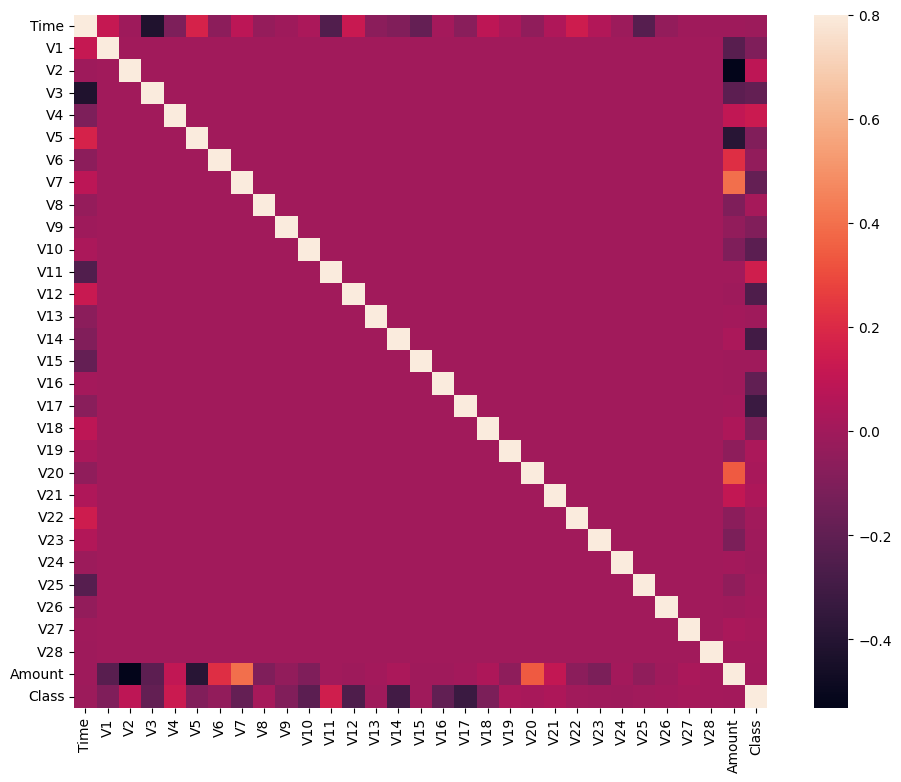

In [7]:
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

In [8]:
X = data.drop(['Class'], axis = 1)
Y = data["Class"]
print(X.shape)
print(Y.shape)

xData = X.values
yData = Y.values

from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(
        xData, yData, test_size = 0.2, random_state = 42)

(284807, 30)
(284807,)


In [9]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(xTrain, yTrain)

yPred = rfc.predict(xTest)

Model Evaluation Metrics:
Accuracy: 0.9996
Precision: 0.9747
Recall: 0.7857
F1-Score: 0.8701
Matthews Correlation Coefficient: 0.8749


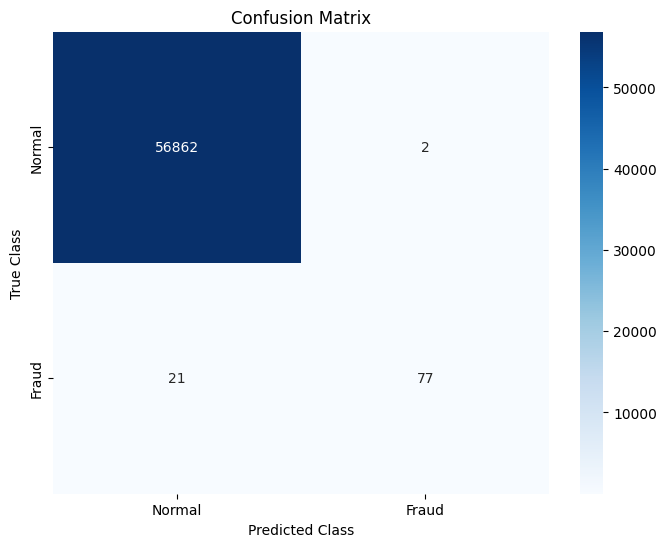

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix 
accuracy = accuracy_score(yTest, yPred)
precision = precision_score(yTest, yPred)
recall = recall_score(yTest, yPred)
f1 = f1_score(yTest, yPred)
mcc = matthews_corrcoef(yTest, yPred)

print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# Modification

In [11]:
from sklearn.ensemble import RandomForestClassifier

rfc2 = RandomForestClassifier(class_weight='balanced')
rfc2.fit(xTrain, yTrain)

yPred2 = rfc2.predict(xTest)

Model Evaluation Metrics:
Accuracy: 0.9996
Precision: 0.9512
Recall: 0.7959
F1-Score: 0.8667
Matthews Correlation Coefficient: 0.8699


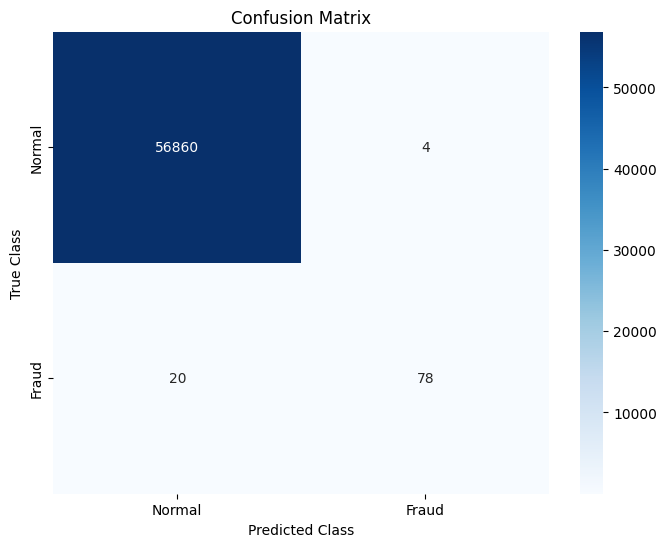

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix 
accuracy = accuracy_score(yTest, yPred2)
precision = precision_score(yTest, yPred2)
recall = recall_score(yTest, yPred2)
f1 = f1_score(yTest, yPred2)
mcc = matthews_corrcoef(yTest, yPred2)

print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

conf_matrix = confusion_matrix(yTest, yPred2)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

Memulai Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== Hyperparameter Terbaik ===
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced'}

=== Model Evaluation Metrics (Setelah Tuning) ===
Accuracy: 0.9996
Precision: 0.9294
Recall: 0.8061
F1-Score: 0.8634
MCC: 0.8654


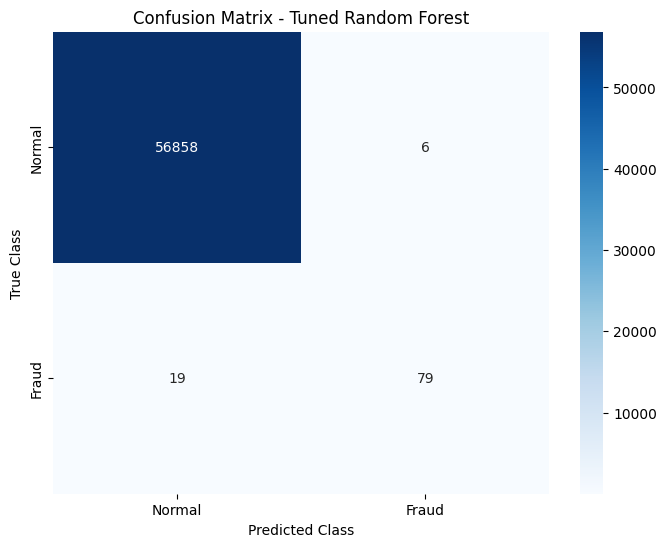

In [13]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definisikan hyperparameter grid yang ingin dieksplorasi
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample'] # Kunci untuk data imbalanced
}

# 2. Inisialisasi model dasar
rfc2 = RandomForestClassifier(random_state=42)

# 3. Setup Randomized Search
# n_iter=10 berarti kita hanya mencoba 10 kombinasi acak untuk menghemat waktu.
# cv=3 berarti 3-fold cross-validation.
# scoring='f1' agar model tetap menjaga keseimbangan, tidak mengorbankan terlalu banyak precision demi recall.
random_search = RandomizedSearchCV(
    estimator=rfc2,
    param_distributions=param_grid,
    n_iter=10, 
    scoring='f1', 
    cv=3, 
    verbose=2, 
    random_state=42,
    n_jobs=-1 # Menggunakan seluruh core CPU laptop/komputer agar lebih cepat
)

# 4. Mulai proses training (PERINGATAN: Ini bisa memakan waktu beberapa menit)
print("Memulai Hyperparameter Tuning...")
random_search.fit(xTrain, yTrain)

# 5. Tampilkan parameter terbaik yang ditemukan
print("\n=== Hyperparameter Terbaik ===")
print(random_search.best_params_)

# 6. Evaluasi menggunakan model terbaik
best_rfc = random_search.best_estimator_
yPred_tuned = best_rfc.predict(xTest)

print("\n=== Model Evaluation Metrics (Setelah Tuning) ===")
print(f"Accuracy: {accuracy_score(yTest, yPred_tuned):.4f}")
print(f"Precision: {precision_score(yTest, yPred_tuned):.4f}")
print(f"Recall: {recall_score(yTest, yPred_tuned):.4f}")
print(f"F1-Score: {f1_score(yTest, yPred_tuned):.4f}")
print(f"MCC: {matthews_corrcoef(yTest, yPred_tuned):.4f}")

# 7. Visualisasi Confusion Matrix Baru
conf_matrix_tuned = confusion_matrix(yTest, yPred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

Distribusi Training Baru: 1182 Normal, 394 Fraud
Melatih model SVC... (Komputasi akan memakan waktu beberapa saat)

=== Model Evaluation Metrics (SVC RBF Kernel) ===
Accuracy: 0.9869
Precision: 0.1057
Recall: 0.8878
F1-Score: 0.1889
MCC: 0.3038


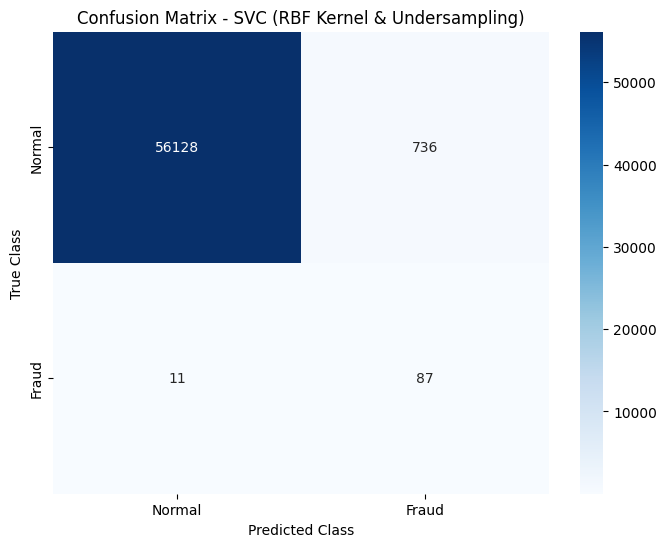

In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Scaling Fitur (Sangat Krusial untuk SVC)
scaler = StandardScaler()
xTrain_scaled = scaler.fit_transform(xTrain)
xTest_scaled = scaler.transform(xTest)

# 2. Manual Undersampling HANYA pada Data Training
# Kita mencari indeks dari masing-class
fraud_indices = np.where(yTrain == 1)[0]
normal_indices = np.where(yTrain == 0)[0]

# Ambil sampel acak dari kelas Normal sebanyak 3x lipat jumlah kelas Fraud (Rasio 1:3)
np.random.seed(42)
normal_sampled_indices = np.random.choice(normal_indices, size=len(fraud_indices) * 3, replace=False)

# Gabungkan indeks dan buat dataset training baru yang sudah di-undersample
undersample_indices = np.concatenate([fraud_indices, normal_sampled_indices])
xTrain_under = xTrain_scaled[undersample_indices]
yTrain_under = yTrain[undersample_indices]

print(f"Distribusi Training Baru: {len(normal_sampled_indices)} Normal, {len(fraud_indices)} Fraud")

# 3. Inisialisasi dan Latih Model SVC dengan RBF Kernel
print("Melatih model SVC... (Komputasi akan memakan waktu beberapa saat)")
svc_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svc_model.fit(xTrain_under, yTrain_under)

# 4. Evaluasi pada Test Set Asli (Imbalanced)
yPred_svc = svc_model.predict(xTest_scaled)

print("\n=== Model Evaluation Metrics (SVC RBF Kernel) ===")
print(f"Accuracy: {accuracy_score(yTest, yPred_svc):.4f}")
print(f"Precision: {precision_score(yTest, yPred_svc):.4f}")
print(f"Recall: {recall_score(yTest, yPred_svc):.4f}")
print(f"F1-Score: {f1_score(yTest, yPred_svc):.4f}")
print(f"MCC: {matthews_corrcoef(yTest, yPred_svc):.4f}")

# 5. Visualisasi Confusion Matrix
conf_matrix_svc = confusion_matrix(yTest, yPred_svc)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svc, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix - SVC (RBF Kernel & Undersampling)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

Memulai Tuning SVC pada data undersample...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Hyperparameter SVC Terbaik ===
{'gamma': 'scale', 'class_weight': None, 'C': 10}

=== Model Evaluation Metrics (Tuned SVC - Undersampled) ===
Accuracy: 0.9937
Precision: 0.2037
Recall: 0.9082
F1-Score: 0.3327
MCC: 0.4284


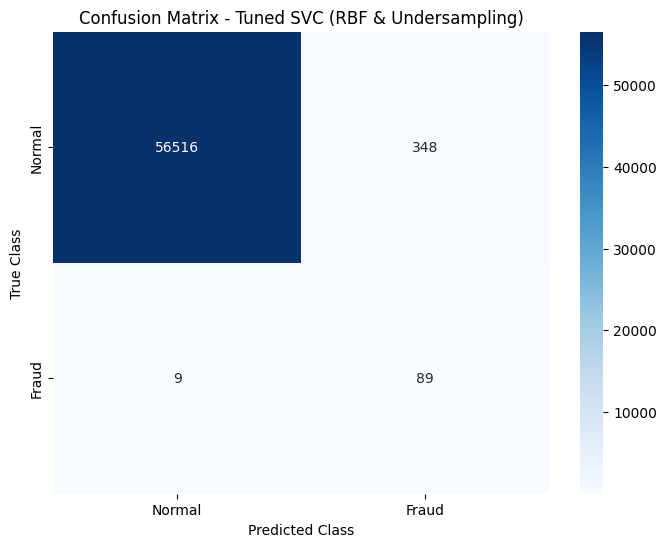

In [15]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Definisikan grid parameter untuk SVC
# Skala logaritmik sering kali paling efektif untuk C dan gamma
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'class_weight': ['balanced', None]
}

# 2. Inisialisasi SVC
svc_base = SVC(kernel='rbf', random_state=42)

# 3. Setup Randomized Search
# Karena dataset undersample sangat kecil, kita bisa menaikkan iterasi menjadi 20 dengan cepat
random_search_svc = RandomizedSearchCV(
    estimator=svc_base,
    param_distributions=param_grid_svc,
    n_iter=20,
    scoring='f1',
    cv=5, # 5-fold CV untuk validasi yang lebih kuat pada data kecil
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 4. Latih HANYA pada data yang sudah di-undersample
# (Pastikan xTrain_under dan yTrain_under dari kode sebelumnya sudah ada di memory)
print("Memulai Tuning SVC pada data undersample...")
random_search_svc.fit(xTrain_under, yTrain_under)

# 5. Lihat parameter terbaik
print("\n=== Hyperparameter SVC Terbaik ===")
print(random_search_svc.best_params_)

# 6. Prediksi ke data TEST ASLI (Scaled)
best_svc = random_search_svc.best_estimator_
yPred_svc_tuned = best_svc.predict(xTest_scaled)

# 7. Evaluasi
print("\n=== Model Evaluation Metrics (Tuned SVC - Undersampled) ===")
print(f"Accuracy: {accuracy_score(yTest, yPred_svc_tuned):.4f}")
print(f"Precision: {precision_score(yTest, yPred_svc_tuned):.4f}")
print(f"Recall: {recall_score(yTest, yPred_svc_tuned):.4f}")
print(f"F1-Score: {f1_score(yTest, yPred_svc_tuned):.4f}")
print(f"MCC: {matthews_corrcoef(yTest, yPred_svc_tuned):.4f}")

# 8. Plot Matrix
conf_matrix_svc_tuned = confusion_matrix(yTest, yPred_svc_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svc_tuned, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix - Tuned SVC (RBF & Undersampling)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

=== Eksekusi 1: SMOTE + Random Forest ===
Distribusi data training RF setelah SMOTE: Normal = 227451, Fraud = 227451
Metrik Random Forest + SMOTE:
Recall: 0.8469 | Precision: 0.8737 | F1: 0.8601

=== Eksekusi 2: Undersampling + SMOTE + SVC (RBF) ===
Distribusi data training SVC setelah kombinasi: Normal = 10000, Fraud = 10000
Metrik SVC + Undersampling + SMOTE:
Recall: 0.9184 | Precision: 0.0876 | F1: 0.1600


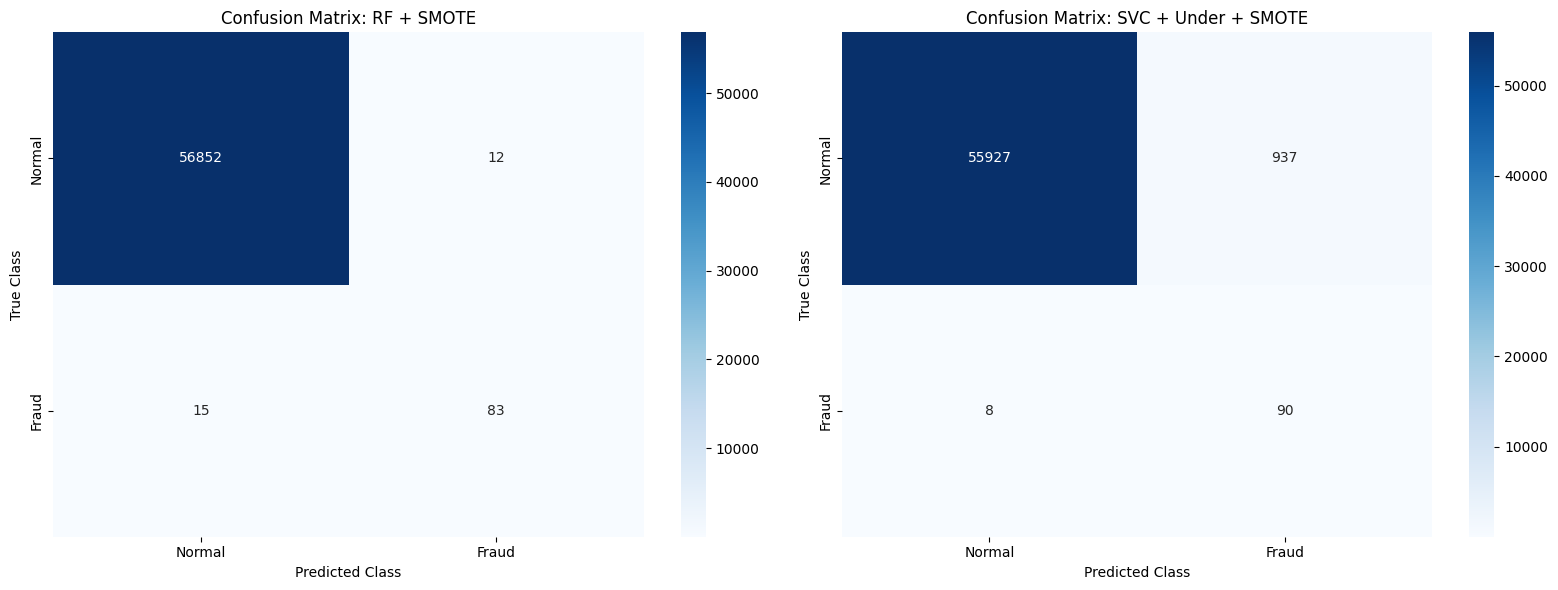

In [16]:
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. SMOTE + RANDOM FOREST
# ==========================================
print("=== Eksekusi 1: SMOTE + Random Forest ===")

# Inisialisasi SMOTE (Oversample Fraud sampai menyamai Normal)
smote_rf = SMOTE(random_state=42)
xTrain_smote_rf, yTrain_smote_rf = smote_rf.fit_resample(xTrain, yTrain)

print(f"Distribusi data training RF setelah SMOTE: Normal = {sum(yTrain_smote_rf==0)}, Fraud = {sum(yTrain_smote_rf==1)}")

# Latih Model Random Forest (Gunakan n_jobs=-1 agar cepat)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(xTrain_smote_rf, yTrain_smote_rf)

# Prediksi dan Evaluasi
yPred_rf_smote = rf_smote.predict(xTest)
print("Metrik Random Forest + SMOTE:")
print(f"Recall: {recall_score(yTest, yPred_rf_smote):.4f} | Precision: {precision_score(yTest, yPred_rf_smote):.4f} | F1: {f1_score(yTest, yPred_rf_smote):.4f}")

# ==========================================
# 2. KOMBINASI UNDERSAMPLING + SMOTE + SVC
# ==========================================
print("\n=== Eksekusi 2: Undersampling + SMOTE + SVC (RBF) ===")

# Tahap 1: Undersampling kelas Normal ke angka yang rasional untuk memori (misal: 10.000)
# Tahap 2: SMOTE kelas Fraud agar seimbang dengan kelas Normal (10.000)
under_sampler = RandomUnderSampler(sampling_strategy={0: 10000}, random_state=42)
smote_svc = SMOTE(sampling_strategy={1: 10000}, random_state=42)

# Rangkai dalam Pipeline agar proses eksekusi berurutan dan aman
pipeline_svc = Pipeline(steps=[
    ('under', under_sampler),
    ('smote', smote_svc)
])

# Aplikasikan ke data yang sudah di-scaling (Ingat: SVC butuh data scaled!)
# Asumsi: xTrain_scaled dan xTest_scaled dari cell SVC sebelumnya masih ada
xTrain_smote_svc, yTrain_smote_svc = pipeline_svc.fit_resample(xTrain_scaled, yTrain)

print(f"Distribusi data training SVC setelah kombinasi: Normal = {sum(yTrain_smote_svc==0)}, Fraud = {sum(yTrain_smote_svc==1)}")

# Latih Model SVC dengan hyperparameter optimal dari tuning sebelumnya (Sesuaikan jika perlu)
# Di sini saya menggunakan parameter default, silakan diganti dengan C dan gamma terbaikmu
svc_smote = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svc_smote.fit(xTrain_smote_svc, yTrain_smote_svc)

# Prediksi dan Evaluasi
yPred_svc_smote = svc_smote.predict(xTest_scaled)
print("Metrik SVC + Undersampling + SMOTE:")
print(f"Recall: {recall_score(yTest, yPred_svc_smote):.4f} | Precision: {precision_score(yTest, yPred_svc_smote):.4f} | F1: {f1_score(yTest, yPred_svc_smote):.4f}")

# ==========================================
# 3. VISUALISASI PERBANDINGAN MATRIX
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot RF
sns.heatmap(confusion_matrix(yTest, yPred_rf_smote), annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[0].set_title("Confusion Matrix: RF + SMOTE")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("True Class")

# Plot SVC
sns.heatmap(confusion_matrix(yTest, yPred_svc_smote), annot=True, fmt="d", cmap="Blues", ax=axes[1], xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[1].set_title("Confusion Matrix: SVC + Under + SMOTE")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("True Class")

plt.tight_layout()
plt.show()